### **Project title:**  
Road Traffic Accident Data Analysis using Python

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


**Load the Road Traffic Accident Dataset**

In [5]:
import pandas as pd

df = pd.read_csv("/content/RTA Dataset -  LMS (1).csv")
print(df.head())
print(df.shape)

print("Dataset loaded successfully!")

       Time Day_of_week Age_band_of_driver Sex_of_driver   Educational_level  \
0  17:02:00      Monday              18-30          Male   Above high school   
1  17:02:00      Monday              31-50          Male  Junior high school   
2  17:02:00      Monday              18-30          Male  Junior high school   
3   1:06:00      Sunday              18-30          Male  Junior high school   
4   1:06:00      Sunday              18-30          Male  Junior high school   

  Vehicle_driver_relation Driving_experience      Type_of_vehicle  \
0                Employee              1-2yr           Automobile   
1                Employee         Above 10yr  Public (> 45 seats)   
2                Employee              1-2yr      Lorry (41?100Q)   
3                Employee             5-10yr  Public (> 45 seats)   
4                Employee              2-5yr                  NaN   

  Owner_of_vehicle Service_year_of_vehicle  ... Vehicle_movement  \
0            Owner              Abov

In [6]:
print(df.describe())

       Number_of_vehicles_involved  Number_of_casualties
count                 12316.000000          12316.000000
mean                      2.040679              1.548149
std                       0.688790              1.007179
min                       1.000000              1.000000
25%                       2.000000              1.000000
50%                       2.000000              1.000000
75%                       2.000000              2.000000
max                       7.000000              8.000000


**Analyze Categorical Variables**

In [7]:
print(df.describe(include="object"))

            Time Day_of_week Age_band_of_driver Sex_of_driver  \
count      12316       12316              12316         12316   
unique      1074           7                  5             3   
top     15:30:00      Friday              18-30          Male   
freq         120        2041               4271         11437   

         Educational_level Vehicle_driver_relation Driving_experience  \
count                11575                   11737              11487   
unique                   7                       4                  7   
top     Junior high school                Employee             5-10yr   
freq                  7619                    9627               3363   

       Type_of_vehicle Owner_of_vehicle Service_year_of_vehicle  ...  \
count            11366            11834                    8388  ...   
unique              17                4                       6  ...   
top         Automobile            Owner                 Unknown  ...   
freq              32

**Understand Dataset Structure and Data Types**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

**Check missing values**

In [9]:
missing = df.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

Defect_of_vehicle          4427
Service_year_of_vehicle    3928
Work_of_casuality          3198
Fitness_of_casuality       2635
Type_of_vehicle             950
Types_of_Junction           887
Driving_experience          829
Educational_level           741
Vehicle_driver_relation     579
Owner_of_vehicle            482
Lanes_or_Medians            385
Vehicle_movement            308
Area_accident_occured       239
Road_surface_type           172
Type_of_collision           155
Road_allignment             142
dtype: int64


**Display the first 5 rows**

In [10]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


**Check Dataset Dimensions**

In [11]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 12316
Number of Columns: 32


**Display All Column Names**

In [12]:
print(df.columns.tolist())

['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


**Calculate Missing Value Percentage**

In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table[missing_table["Missing Values"] > 0].sort_values(
    "Percentage",
    ascending=False
)

,Missing Values,Percentage
Defect_of_vehicle,4427,35.945112
Service_year_of_vehicle,3928,31.893472
Work_of_casuality,3198,25.966223
Fitness_of_casuality,2635,21.394933
Type_of_vehicle,950,7.713543
Types_of_Junction,887,7.202014
Driving_experience,829,6.731082
Educational_level,741,6.016564
Vehicle_driver_relation,579,4.701202
Owner_of_vehicle,482,3.913608


**Check for Duplicate Records**

In [14]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Exploratory Data Analysis**   
Accident Severity Distribution

In [15]:
df["Accident_severity"].value_counts()

,count
Accident_severity,
Slight Injury,10415
Serious Injury,1743
Fatal injury,158


**Visualization of Accident Severity**

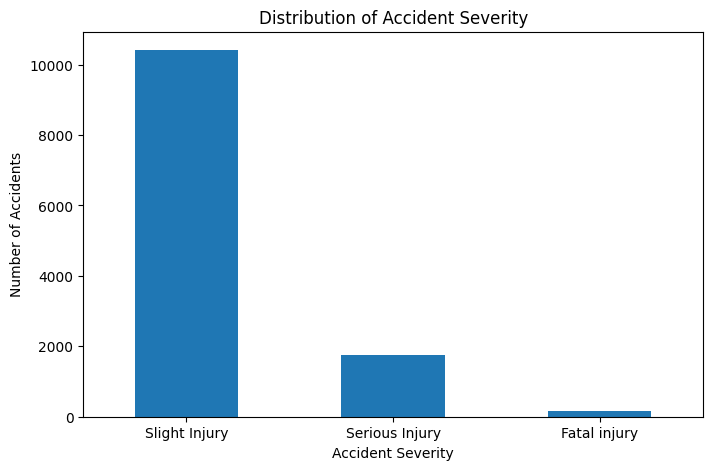

In [16]:
plt.figure(figsize=(8,5))

df["Accident_severity"].value_counts().plot(kind="bar")

plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.show()

**Accident Severity Percentage Analysis**

In [17]:
df["Accident_severity"].value_counts(normalize=True) * 100

,proportion
Accident_severity,
Slight Injury,84.564794
Serious Injury,14.152322
Fatal injury,1.282884


**Accidents by Day of the Week**

In [18]:
day_counts = df["Day_of_week"].value_counts()
print(day_counts)

Day_of_week
Friday       2041
Thursday     1851
Wednesday    1840
Tuesday      1770
Monday       1681
Saturday     1666
Sunday       1467
Name: count, dtype: int64


**Visualization of Accidents by Day**

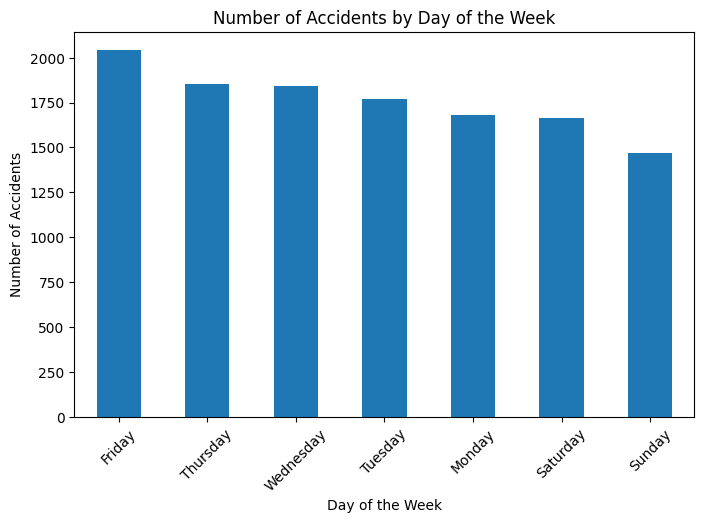

In [19]:
plt.figure(figsize=(8,5))

day_counts.plot(kind="bar")

plt.title("Number of Accidents by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

**Accidents by Driver Age Group**

In [20]:
df["Age_band_of_driver"].value_counts()

,count
Age_band_of_driver,
18-30,4271
31-50,4087
Over 51,1585
Unknown,1548
Under 18,825


**Visualization of Accidents by Age Group**

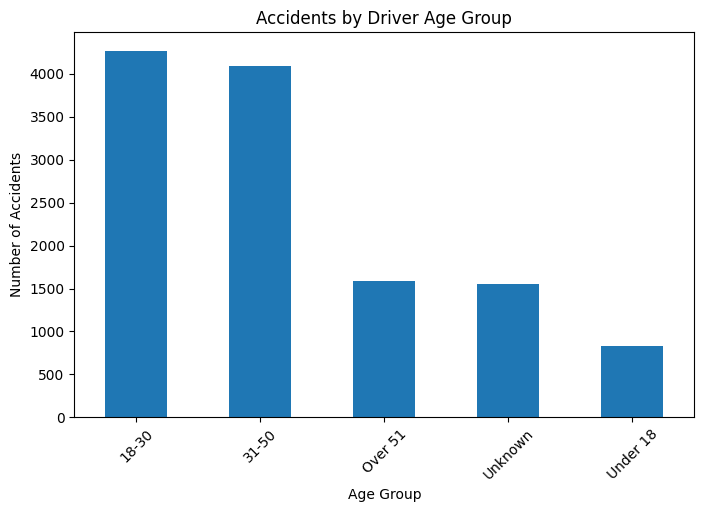

In [22]:
plt.figure(figsize=(8,5))

df["Age_band_of_driver"].value_counts().plot(kind="bar")

plt.title("Accidents by Driver Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

**Accidents by Driver Gender**

In [23]:
df["Sex_of_driver"].value_counts()

,count
Sex_of_driver,
Male,11437
Female,701
Unknown,178


**Visualization of Driver Gender**

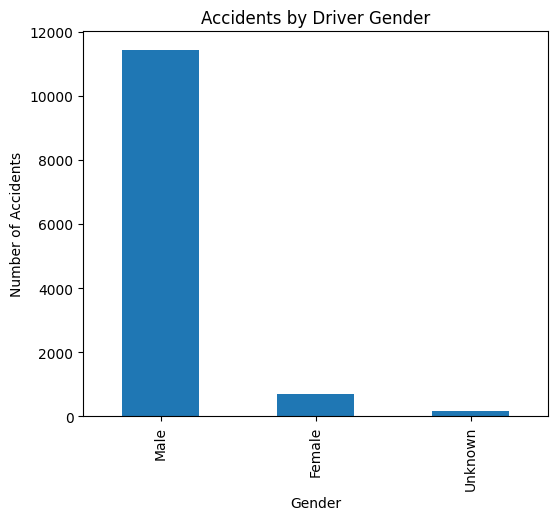

In [24]:
plt.figure(figsize=(6,5))

df["Sex_of_driver"].value_counts().plot(kind="bar")

plt.title("Accidents by Driver Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Accidents")
plt.show()

 **Accidents by Driving Experience**

In [25]:
df["Driving_experience"].value_counts()

,count
Driving_experience,
5-10yr,3363
2-5yr,2613
Above 10yr,2262
1-2yr,1756
Below 1yr,1342
No Licence,118
unknown,33


**Visualization of Driving Experience**

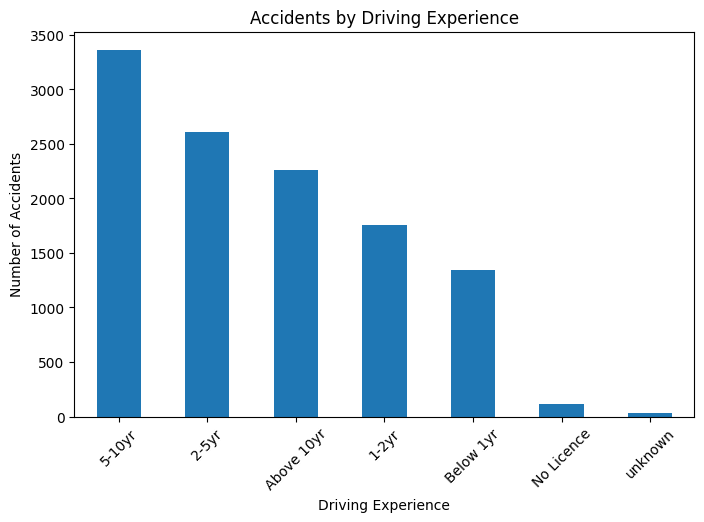

In [26]:
plt.figure(figsize=(8,5))

df["Driving_experience"].value_counts().plot(kind="bar")

plt.title("Accidents by Driving Experience")
plt.xlabel("Driving Experience")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

**Analysis of Accident Causes**

In [27]:
df["Cause_of_accident"].value_counts()

,count
Cause_of_accident,
No distancing,2263
Changing lane to the right,1808
Changing lane to the left,1473
Driving carelessly,1402
No priority to vehicle,1207
Moving Backward,1137
No priority to pedestrian,721
Other,456
Overtaking,430


**Top 10 Causes of Road Accidents**

In [28]:
top_causes = df["Cause_of_accident"].value_counts().head(10)

top_causes

,count
Cause_of_accident,
No distancing,2263
Changing lane to the right,1808
Changing lane to the left,1473
Driving carelessly,1402
No priority to vehicle,1207
Moving Backward,1137
No priority to pedestrian,721
Other,456
Overtaking,430


**Visualization of Top Accident Causes**

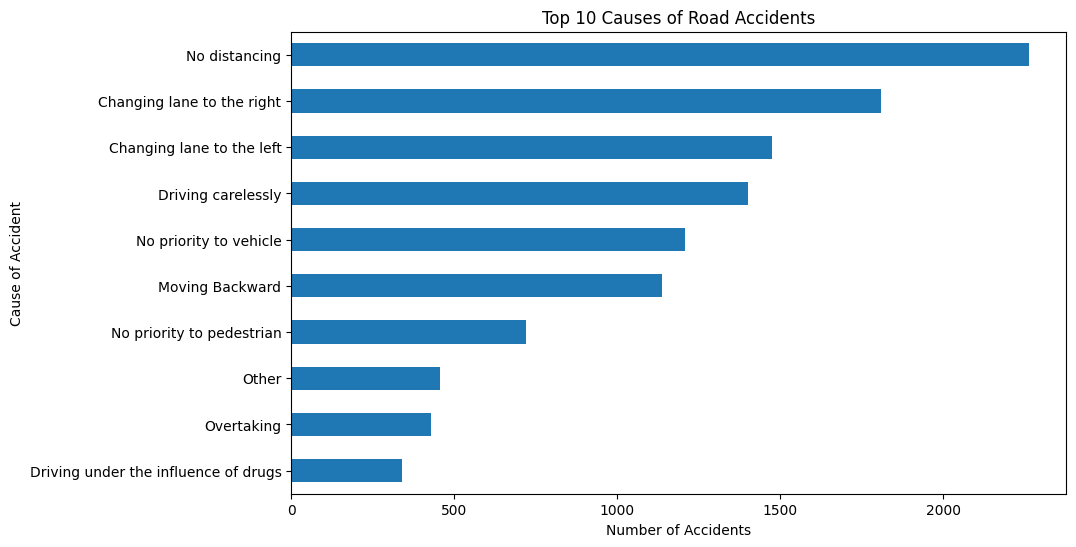

In [29]:
plt.figure(figsize=(10,6))

top_causes.sort_values().plot(kind="barh")

plt.title("Top 10 Causes of Road Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Cause of Accident")
plt.show()

**Analysis of Weather Conditions**

In [30]:
df["Weather_conditions"].value_counts()

,count
Weather_conditions,
Normal,10063
Raining,1331
Other,296
Unknown,292
Cloudy,125
Windy,98
Snow,61
Raining and Windy,40
Fog or mist,10


**Visualization of Weather Conditions**

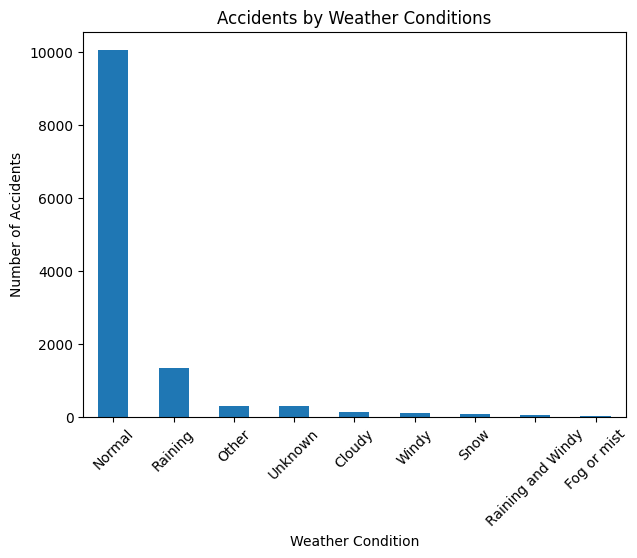

In [31]:
plt.figure(figsize=(7,5))

df["Weather_conditions"].value_counts().plot(kind="bar")

plt.title("Accidents by Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

**Analysis of Road Surface Conditions**

In [32]:
df["Road_surface_conditions"].value_counts()

,count
Road_surface_conditions,
Dry,9340
Wet or damp,2904
Snow,70
Flood over 3cm. deep,2


**Time Analysis**  
Convert Accident Time into Time Format

In [33]:
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S",
    errors="coerce"
)

**Extract Accident Hour**

In [34]:
df["Hour"] = df["Time"].dt.hour

df[["Time", "Hour"]].head()

,Time,Hour
0,1900-01-01 17:02:00,17
1,1900-01-01 17:02:00,17
2,1900-01-01 17:02:00,17
3,1900-01-01 01:06:00,1
4,1900-01-01 01:06:00,1


**Accidents by Hour of the Day**

In [35]:
hour_counts = df["Hour"].value_counts().sort_index()

hour_counts

,count
Hour,
0,206
1,134
2,84
3,84
4,91
5,76
6,214
7,532
8,828


**Visualization of Accidents by Hour**

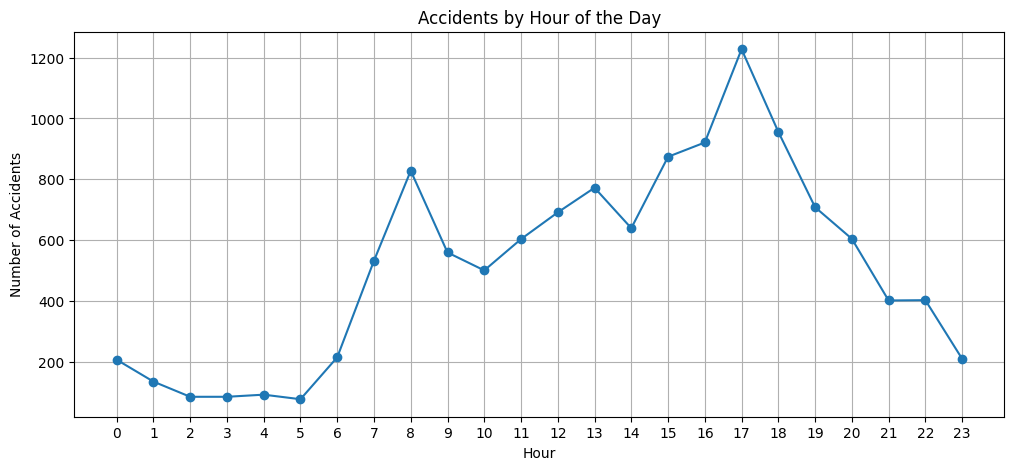

In [36]:
plt.figure(figsize=(12,5))

hour_counts.plot(kind="line", marker="o")

plt.title("Accidents by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.xticks(range(24))
plt.grid()
plt.show()

**Statistical Analysis**   
Descriptive Statistics of Vehicles and Casualties


In [37]:
numeric_cols = [
    "Number_of_vehicles_involved",
    "Number_of_casualties"
]

df[numeric_cols].describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


**Calculate Mean**

In [38]:
df[numeric_cols].mean()

,0
Number_of_vehicles_involved,2.040679
Number_of_casualties,1.548149


**Calculate Median of Vehicles and Casualties**

In [39]:
df[numeric_cols].median()

,0
Number_of_vehicles_involved,2.0
Number_of_casualties,1.0


**Calculate Mode of Vehicles and Casualties**

In [40]:
df[numeric_cols].mode().iloc[0]

,0
Number_of_vehicles_involved,2
Number_of_casualties,1


**Calculate Standard Deviation**

In [41]:
df[numeric_cols].std()

,0
Number_of_vehicles_involved,0.688790
Number_of_casualties,1.007179


**Calculate Variance**

In [42]:
df[numeric_cols].var()

,0
Number_of_vehicles_involved,0.474431
Number_of_casualties,1.014409


**Calculate Range**

In [43]:
for col in numeric_cols:
    print(col, "Range =", df[col].max() - df[col].min())

Number_of_vehicles_involved Range = 6
Number_of_casualties Range = 7


**Calculate Quartiles and Interquartile Range**

In [44]:
Q1 = df["Number_of_casualties"].quantile(0.25)
Q3 = df["Number_of_casualties"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 1.0
Q3: 2.0
IQR: 1.0


**Outlier Detection Using IQR Method**

In [45]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Number_of_casualties"] < lower_limit) |
    (df["Number_of_casualties"] > upper_limit)
]

print("Number of outliers:", len(outliers))

Number of outliers: 720


**Boxplot of Number of Casualties**

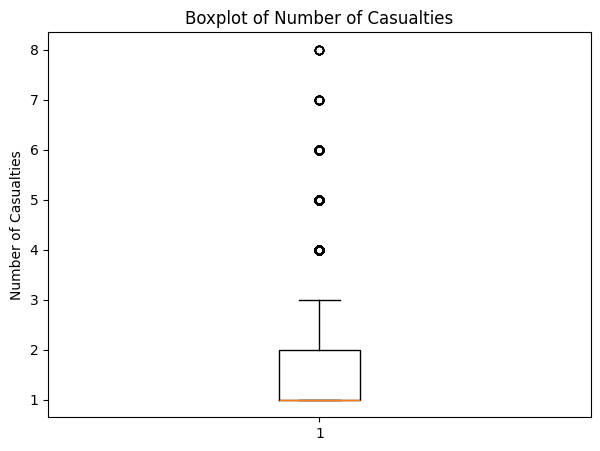

In [46]:
plt.figure(figsize=(7,5))

plt.boxplot(df["Number_of_casualties"].dropna())

plt.title("Boxplot of Number of Casualties")
plt.ylabel("Number of Casualties")
plt.show()

**Correlation Analysis**  
Correlation Between Vehicles and Casualties

In [47]:
correlation = df[
    ["Number_of_vehicles_involved",
     "Number_of_casualties"]
].corr()

correlation

,Number_of_vehicles_involved,Number_of_casualties
Number_of_vehicles_involved,1.000000,0.213427
Number_of_casualties,0.213427,1.000000


**Correlation Heatmap**

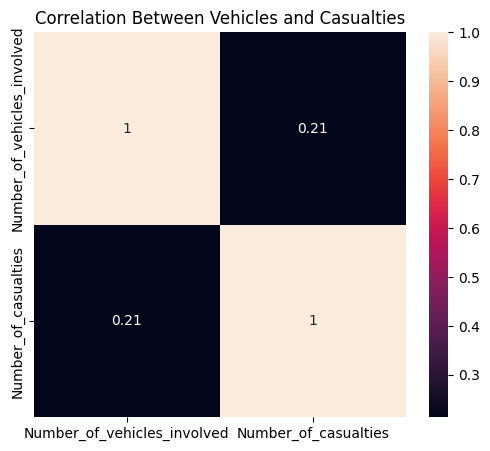

In [48]:
plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Between Vehicles and Casualties")
plt.show()

**VISUALISATION**  
DISTRIBUTION PLOT - CASUALTIES

VISUALISATION - CASUALTY DISTRIBUTION


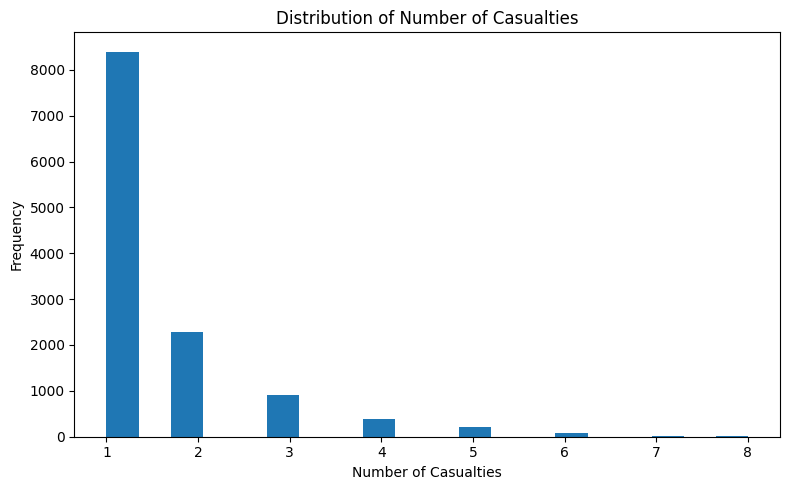

In [49]:

print("VISUALISATION - CASUALTY DISTRIBUTION")
plt.figure(figsize=(8, 5))
plt.hist(
    df["Number_of_casualties"].dropna(),
    bins=20
)
plt.title(
    "Distribution of Number of Casualties"
)
plt.xlabel(
    "Number of Casualties"
)
plt.ylabel(
    "Frequency"
)
plt.tight_layout()
plt.show()


**KEY INSIGHTS**

In [50]:
df.columns = df.columns.str.strip()

highest_vehicle = df["Type_of_vehicle"].value_counts().idxmax()
highest_vehicle_count = df["Type_of_vehicle"].value_counts().max()

highest_severity = df["Accident_severity"].value_counts().idxmax()
severity_count = df["Accident_severity"].value_counts().max()

common_cause = df["Cause_of_accident"].value_counts().idxmax()
cause_count = df["Cause_of_accident"].value_counts().max()

common_weather = df["Weather_conditions"].value_counts().idxmax()

common_light = df["Light_conditions"].value_counts().idxmax()

common_road_condition = df["Road_surface_conditions"].value_counts().idxmax()

avg_vehicles = df["Number_of_vehicles_involved"].mean()

avg_casualties = df["Number_of_casualties"].mean()

print("   ----- KEY INSIGHTS -----")
print("1. Most common vehicle type:", highest_vehicle)
print("   Number of accidents:", highest_vehicle_count)

print("2. Most common accident severity:", highest_severity)
print("   Number of accidents:", severity_count)

print("3. Most common accident cause:", common_cause)
print("   Number of accidents:", cause_count)

print("4. Most common weather condition:", common_weather)
print("5. Most common light condition:", common_light)
print("6. Most common road condition:", common_road_condition)

print("7. Average vehicles involved:", round(avg_vehicles, 2))
print("8. Average casualties:", round(avg_casualties, 2))

   ----- KEY INSIGHTS -----
1. Most common vehicle type: Automobile
   Number of accidents: 3205
2. Most common accident severity: Slight Injury
   Number of accidents: 10415
3. Most common accident cause: No distancing
   Number of accidents: 2263
4. Most common weather condition: Normal
5. Most common light condition: Daylight
6. Most common road condition: Dry
7. Average vehicles involved: 2.04
8. Average casualties: 1.55


### **Recommendations**

In [51]:
print("----- RECOMMENDATIONS -----")

common_cause = df["Cause_of_accident"].value_counts().idxmax()
print(f"1. Focus on reducing accidents caused by '{common_cause}'.")

common_vehicle = df["Type_of_vehicle"].value_counts().idxmax()
print(f"2. Provide safety awareness and training for '{common_vehicle}' users.")

common_weather = df["Weather_conditions"].value_counts().idxmax()
print(f"3. Improve road safety measures during '{common_weather}' conditions.")

common_light = df["Light_conditions"].value_counts().idxmax()
print(f"4. Improve street lighting and visibility during '{common_light}' conditions.")

common_road = df["Road_surface_conditions"].value_counts().idxmax()
print(f"5. Maintain roads properly, especially during '{common_road}' conditions.")

severity = df["Accident_severity"].value_counts().idxmax()
print(f"6. Take additional safety measures to reduce '{severity}' accidents.")

----- RECOMMENDATIONS -----
1. Focus on reducing accidents caused by 'No distancing'.
2. Provide safety awareness and training for 'Automobile' users.
3. Improve road safety measures during 'Normal' conditions.
4. Improve street lighting and visibility during 'Daylight' conditions.
5. Maintain roads properly, especially during 'Dry' conditions.
6. Take additional safety measures to reduce 'Slight Injury' accidents.


**PROJECT CONCLUSION**

In [52]:
print("-------------- FINAL CONCLUSION ---------------")

print("""
The analysis of the accident dataset shows that road accidents
are influenced by factors such as vehicle type, accident causes,
weather conditions, lighting conditions, and road conditions.

The key insights help identify the major factors associated with
road accidents and their severity. Based on these findings,
improving road conditions, providing better lighting, increasing
driver awareness, and implementing preventive safety measures
can help reduce the number and severity of accidents.

Overall, data analysis can support better road-safety planning
and help authorities take effective preventive actions.
""")

-------------- FINAL CONCLUSION ---------------

The analysis of the accident dataset shows that road accidents
are influenced by factors such as vehicle type, accident causes,
weather conditions, lighting conditions, and road conditions.

The key insights help identify the major factors associated with
road accidents and their severity. Based on these findings,
improving road conditions, providing better lighting, increasing
driver awareness, and implementing preventive safety measures
can help reduce the number and severity of accidents.

Overall, data analysis can support better road-safety planning
and help authorities take effective preventive actions.

